In [1]:
import numpy as np, basic, cosmology, local, tools_multitracer as mass, plottools as pl
from matplotlib.pyplot import *

In [2]:
lmax = 1024
euc_zbin = 5
lss_zbin = 5

In [3]:
frac = mass.galaxy_distribution(np.linspace(0,50,1000),zbn={'euc':euc_zbin,'lss':lss_zbin})[3]

In [4]:
l, camb_cls = mass.read_camb_cls(add_euc=euc_zbin,add_lss=lss_zbin)

In [5]:
# for cross spectrum
vecs, ocov = {}, {}
Scov = mass.get_covariance_signal(lmax,add_cmb=['klb'],add_euc=euc_zbin,add_lss=lss_zbin)
print(np.shape(Scov))

(12, 12, 1025)


In [6]:
# LB
sklb = mass.get_covariance_signal(lmax,add_cmb=['klb'],add_euc=0,add_lss=0,add_cib=False)
nklb = mass.get_covariance_noise(lmax,add_cmb=['klb'],add_euc=0,add_lss=0,add_cib=False)
vecs['klb'] = Scov[0,0:1,:]
ocov['klb'] = sklb + nklb

In [7]:
# LB+CIB
scib = mass.get_covariance_signal(lmax,add_cmb=['klb'],add_euc=0,add_lss=0)
ncib = mass.get_covariance_noise(lmax,add_cmb=['klb'],add_euc=0,add_lss=0)
vecs['cib'] = Scov[0,0:2,:]
ocov['cib'] = scib + ncib

In [8]:
# gal covariance
sgal = mass.get_covariance_signal(lmax,add_cmb=['klb'],add_cib=False,add_euc=euc_zbin,add_lss=lss_zbin)
ngal = mass.get_covariance_noise(lmax,frac=frac,add_cmb=['klb'],add_cib=False,add_euc=euc_zbin,add_lss=lss_zbin)
vecs['gal'] = np.delete(Scov[0,0:2+euc_zbin+lss_zbin,:],1,0)
ocov['gal'] = sgal + ngal

In [9]:
# cib+gal covariance
sext = mass.get_covariance_signal(lmax,add_cmb=['klb'],add_euc=euc_zbin,add_lss=lss_zbin)
next = mass.get_covariance_noise(lmax,frac=frac,add_cmb=['klb'],add_euc=euc_zbin,add_lss=lss_zbin)
vecs['ext'] = Scov[0,0:2+euc_zbin+lss_zbin,:]
ocov['ext'] = sext + next

In [10]:
# cib+gal covariance
Scovs4 = mass.get_covariance_signal(lmax,add_cmb=['klb','ks4'],add_euc=euc_zbin,add_lss=lss_zbin)
print(np.shape(Scovs4))
sext = mass.get_covariance_signal(lmax,add_cmb=['klb','ks4'],add_euc=euc_zbin,add_lss=lss_zbin)
next = mass.get_covariance_noise(lmax,frac=frac,add_cmb=['klb','ks4'],add_euc=euc_zbin,add_lss=lss_zbin)
vecs['all'] = Scovs4[0,0:3+euc_zbin+lss_zbin,:]
ocov['all'] = sext + next

(13, 13, 1025)


In [11]:
icov, rho = {}, {}
#for t in ['cib','gal','ext','all']:
for t in ['klb','cib','gal','ext','all']:
    icov[t] = ocov[t].copy()
    icov[t][:,:,2:] = np.array( [ np.linalg.inv(ocov[t][:,:,l]) for l in range(2,lmax+1) ] ).T
    rho[t] = np.array( [ np.dot( vecs[t][:,l], np.dot( icov[t][:,:,l], vecs[t][:,l] ) ) for l in range(lmax+1) ] ) / ( camb_cls['klbklb'][:lmax+1] + 1e-30 )

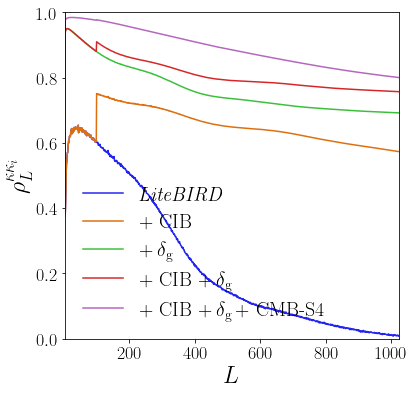

In [20]:
pl.plot_1dstyle(fsize=[6,6],usetex=True,xmin=2,xmax=lmax,ymin=0,ymax=1,xlab=r'$L$',ylab=r'$\rho^{\kappa\kappa_i}_L$',
                xlabsize=24,ylabsize=24,
                xticks_labsize=18,yticks_labsize=18,legend_size=20)
rcParams["font.family"] = "Arial"
for t, label in [('klb',r'{\it LiteBIRD}'),
                 ('cib',r'$+$ CIB'),
                 ('gal',r'$+\,\delta_{\rm g}$'),
                 ('ext',r'$+$ CIB $+\,\delta_{\rm g}$'),
                 ('all',r'$+$ CIB $+\,\delta_{\rm g}\,+$ CMB-S4')]:
    plot(l[:lmax+1], np.sqrt(rho[t]),label=label)
legend(loc=0)
savefig('fig_rho_add-lb.pdf',bbox_inches = 'tight', pad_inches = 0.1)